In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pickle

from pprint import pprint

file_dir = 'thinker-20250623-172121-3017184-0/video_stat.npy'
data_dir = os.path.join('../test', file_dir)

In [2]:
print(data_dir)

../test/thinker-20250623-172121-3017184-0/video_stat.npy


In [3]:
data = (np.load(data_dir, allow_pickle=True)).item()

print('data.keys():', data.keys())
print('real image data length:', len(data['real_imgs']))
print('imagination image data length:', len(data['im_imgs']))


data.keys(): dict_keys(['real_imgs', 'im_imgs', 'status', 'tree_reps'])
real image data length: 18514
imagination image data length: 18514


# im_image: list

In [4]:
data['im_imgs']

AttributeError: 'list' object has no attribute 'shape'

# tree_reps: list


In [9]:
from collections import defaultdict
from pprint import pprint

keys = [
    'root_action', 'root_r', 'root_d', 'root_v', 'root_policy',
    'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r',
    'rollout_return', 'max_rollout_return', 'root_raw_action',
    'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy',
    'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action',
    'cur_reset', 'k', 'deprec', 'action_seq'
]

grouped = defaultdict(list)
for key in keys:
    prefix = key.split('_')[0]
    grouped[prefix].append(key)

pprint(dict(grouped))

{'action': ['action_seq'],
 'cur': ['cur_action',
         'cur_r',
         'cur_d',
         'cur_v',
         'cur_policy',
         'cur_qs_mean',
         'cur_qs_max',
         'cur_ns',
         'cur_raw_action',
         'cur_reset'],
 'deprec': ['deprec'],
 'k': ['k'],
 'max': ['max_rollout_return'],
 'rollout': ['rollout_return'],
 'root': ['root_action',
          'root_r',
          'root_d',
          'root_v',
          'root_policy',
          'root_qs_mean',
          'root_qs_max',
          'root_ns',
          'root_trail_r',
          'root_raw_action']}


In [10]:
# blen(data['status'])
data['tree_reps']['action_seq'].shape

(18514, 66)

In [40]:
# data['status']에서 각 값의 개수 계산
status_values = [0, 1, 2, 3]  # 계산하려는 status 값들
status_counts = {}

for value in status_values:
    # 해당 값을 가진 인덱스의 개수 계산
    count = np.sum(np.array(data['status']) == value)
    status_counts[value] = count

# 결과 출력
for value, count in status_counts.items():
    status_name = {
        0: "실제 스텝(real step)",
        1: "리셋(reset)",
        2: "상상 스텝(imaginary step)",
        3: "강제 리셋(force reset)"
    }.get(value, "알 수 없음")
    
    print(f"Status {value} ({status_name}): {count}개")

# 특정 값(예: 0)을 가진 인덱스 목록 구하기
indices_with_value_0 = np.where(np.array(data['status']) == 0)[0]
print(f"\nStatus 0을 가진 인덱스의 개수: {len(indices_with_value_2)}")

Status 0 (실제 스텝(real step)): 834개
Status 1 (리셋(reset)): 238개
Status 2 (상상 스텝(imaginary step)): 15827개
Status 3 (강제 리셋(force reset)): 1615개

Status 0을 가진 인덱스의 개수: 834


tree_reps의 키: ['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'rollout_return', 'max_rollout_return', 'root_raw_action', 'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy', 'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action', 'cur_reset', 'k', 'deprec', 'action_seq']
첫 번째 인덱스 0의 tree_reps 구조:
  - root_action: <class 'numpy.ndarray'>
    형태: (18514, 6)
    첫 번째 인덱스 값: [1. 0. 0. 0. 0. 0.]
  - root_r: <class 'numpy.ndarray'>
    형태: (18514, 1)
    첫 번째 인덱스 값: [0.]
  - root_d: <class 'numpy.ndarray'>
    형태: (18514, 1)
    첫 번째 인덱스 값: [0.]
  - root_v: <class 'numpy.ndarray'>
    형태: (18514, 1)
    첫 번째 인덱스 값: [3.7418723]
  - root_policy: <class 'numpy.ndarray'>
    형태: (18514, 6)
    첫 번째 인덱스 값: [-6.359848   -0.987524   -7.2048545  -6.409294    1.9676012   0.05324408]
  - root_qs_mean: <class 'numpy.ndarray'>
    형태: (18514, 6)
    첫 번째 인덱스 값: [0. 0. 0. 0. 0. 0.]
  - root_qs_max: <class 'numpy.ndarray'>
    형태: (

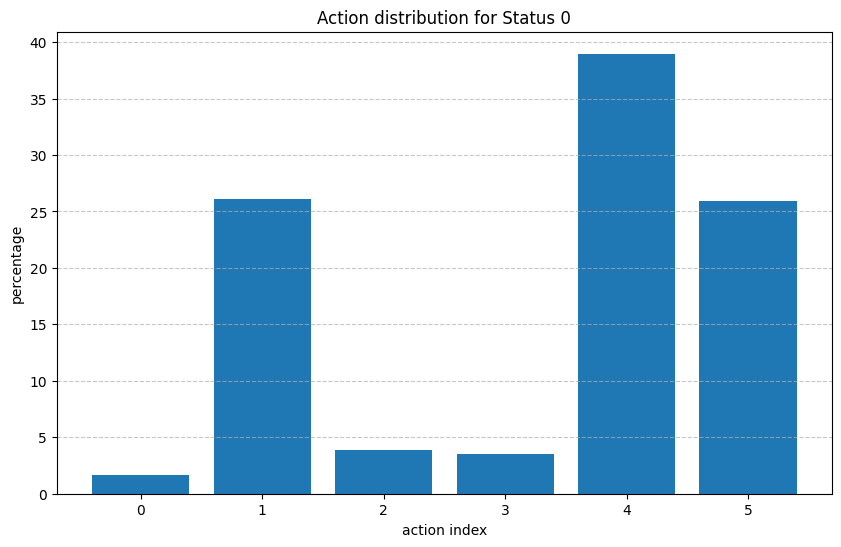

In [ ]:
# 먼저 tree_reps의 구조를 확인
print("tree_reps의 키:", list(data['tree_reps'].keys()))

# 데이터 구조에 따라 접근 방식 수정
action_distributions = []

# 데이터 구조 확인을 위한 코드
first_idx = indices_with_value_0[0]
print(f"첫 번째 인덱스 {first_idx}의 tree_reps 구조:")
for key in data['tree_reps'].keys():
    print(f"  - {key}: {type(data['tree_reps'][key])}")
    if isinstance(data['tree_reps'][key], np.ndarray):
        print(f"    형태: {data['tree_reps'][key].shape}")
        if len(data['tree_reps'][key]) > first_idx:
            print(f"    첫 번째 인덱스 값: {data['tree_reps'][key][first_idx]}")

# 'current_action' 키가 있다면 다음과 같이 진행
if 'current_action' in data['tree_reps']:
    for idx in indices_with_value_0:
        current_action = data['tree_reps']['current_action'][idx]
        action_distributions.append(current_action)
    
    # numpy 배열로 변환
    action_distributions = np.array(action_distributions)
    
    # 각 액션의 분포 계산
    if len(action_distributions.shape) > 1:  # one-hot 벡터인 경우
        action_counts = np.sum(action_distributions, axis=0)
        action_distribution_percentage = action_counts / len(indices_with_value_0) * 100
        
        # 결과 출력
        print("\naction distribution:")
        for i, percentage in enumerate(action_distribution_percentage):
            print(f"action {i}: {percentage:.2f}%")
        
        # 시각화
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(action_distribution_percentage)), action_distribution_percentage)
        plt.xlabel('action index')
        plt.ylabel('percentage')
        plt.title('Action distribution for Status 0')
        plt.xticks(range(len(action_distribution_percentage)))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:  # 단일 값인 경우
        unique_actions, counts = np.unique(action_distributions, return_counts=True)
        percentages = counts / len(indices_with_value_0) * 100
        
        print("\naction disstribution:")
        for action, percentage in zip(unique_actions, percentages):
            print(f"action {action}: {percentage:.2f}%")
        
        plt.figure(figsize=(10, 6))
        plt.bar(unique_actions, percentages)
        plt.xlabel('action')
        plt.ylabel('percentage')
        plt.title('Action distribution for Status 0')
        plt.xticks(unique_actions)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
else:
    print("'current_action' 키를 찾을 수 없습니다. 사용 가능한 키를 확인하세요.")

In [6]:
data['tree_reps'].keys()

dict_keys(['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'rollout_return', 'max_rollout_return', 'root_raw_action', 'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy', 'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action', 'cur_reset', 'k', 'deprec', 'action_seq'])

In [ ]:
data['tree_reps'].shape

(18514, 1)

In [25]:
len(data['real_imgs'])

18514

gym test